# Analisys

## Source golden tables

In [153]:
gold_source = (
    "/home/baptvit/Documents/github/graphrag-on-fhir/evaluations/data/gold/microsoft/"
)

In [154]:
import glob
import os

import pandas as pd

all_files = glob.glob(os.path.join(gold_source, "*.csv"))

df_gold = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)

In [155]:
df_gold.columns

Index(['consumer_id', 'experiment_1', 'expriment_1_name', 'experiment_2',
       'expriment_2_name', 'experiment_1_output', 'experiment_2_output',
       'model_evaluation', 'response', 'comprehensiveness', 'diversity',
       'empowerment', 'directness', 'overall_winner'],
      dtype='object')

In [156]:
target_df = df_gold[
    [
        "consumer_id",
        "experiment_1",
        "experiment_2",
        "expriment_1_name",
        "expriment_2_name",
        "model_evaluation",
        "response",
        "comprehensiveness",
        "diversity",
        "empowerment",
        "directness",
        "overall_winner",
    ]
]

## Filter only the L0 and L1 results for BRACIS

In [110]:
filter_in = ["LexicalSearch1HopStrategy", "LexicalSearch0HopStrategy"]

In [111]:
target_df = target_df[target_df["expriment_1_name"].isin(filter_in) & target_df["expriment_2_name"].isin(filter_in)]

## Filter only the S0 and S1 results for BRACIS

In [157]:
filter_in = ["SimilaritySearch0HopStrategy", "SimilaritySearch1HopStrategy"]

In [158]:
target_df = target_df[target_df["expriment_1_name"].isin(filter_in) & target_df["expriment_2_name"].isin(filter_in)]

In [159]:
target_df.count()

consumer_id          200
experiment_1         200
experiment_2         200
expriment_1_name     200
expriment_2_name     200
model_evaluation     200
response             200
comprehensiveness    195
diversity            195
empowerment          195
directness           195
overall_winner       195
dtype: int64

In [160]:
target_df[target_df["empowerment"].isna()]

,consumer_id,experiment_1,experiment_2,expriment_1_name,expriment_2_name,model_evaluation,response,comprehensiveness,diversity,empowerment,directness,overall_winner
70,Jacklyn830_Veum823_e0e1f21a-22a7-d166-7bb1-63f...,Q8:gemini-1.5-pro:similarity_search_0_hop,Q8:gemini-1.5-pro:similarity_search_1_hop,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,"```json\n{\n ""Comprehensiveness"": {\n ...","content='```json\n{\n ""Comprehensiveness"": ...",NaN,NaN,NaN,NaN,NaN
88,Jacklyn830_Veum823_e0e1f21a-22a7-d166-7bb1-63f...,Q7:gemini-1.5-pro:similarity_search_0_hop,Q7:gemini-1.5-pro:similarity_search_1_hop,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,"```json\n{\n ""Comprehensiveness"": {\n ...","content='```json\n{\n ""Comprehensiveness"": ...",NaN,NaN,NaN,NaN,NaN
362,Jacklyn830_Veum823_e0e1f21a-22a7-d166-7bb1-63f...,Q2:llama-3-70b-instruct-awq:similarity_search_...,Q2:llama-3-70b-instruct-awq:similarity_search_...,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,"{'Comprehensiveness': {'Winner': 'None', 'Expl...","content='```json\n{\n ""Comprehensiveness"": ...",NaN,NaN,NaN,NaN,NaN
650,Milton509_Ortiz186_d66b5418-06cb-fc8a-8c13-856...,Q2:gpt-4o-2024-08-06:similarity_search_0_hop,Q2:gpt-4o-2024-08-06:similarity_search_1_hop,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,"{'Comprehensiveness': {'Winner': 'None', 'Expl...","content='```json\n{\n ""Comprehensiveness"": ...",NaN,NaN,NaN,NaN,NaN
1034,Milton509_Ortiz186_d66b5418-06cb-fc8a-8c13-856...,Q2:gpt-4o-2024-08-06:similarity_search_0_hop,Q2:gpt-4o-2024-08-06:similarity_search_1_hop,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,"{'Comprehensiveness': {'Winner': 'None', 'Expl...","content='```json\n{\n ""Comprehensiveness"": ...",NaN,NaN,NaN,NaN,NaN


In [161]:
target_df.count()

consumer_id          200
experiment_1         200
experiment_2         200
expriment_1_name     200
expriment_2_name     200
model_evaluation     200
response             200
comprehensiveness    195
diversity            195
empowerment          195
directness           195
overall_winner       195
dtype: int64

## Dealing with the nan values by adding a new way to extract the values

In [162]:
import re

def extract_winners_txt_v2(text):
    # Define regex patterns to capture the winners for each section
    patterns = {
        "comprehensiveness": r'"Comprehensiveness":\s*{\s*"Winner":\s*"([^"]+)"',
        "diversity": r'"Diversity":\s*{\s*"Winner":\s*"([^"]+)"',
        "empowerment": r'"Empowerment":\s*{\s*"Winner":\s*"([^"]+)"',
        "directness": r'"Directness":\s*{\s*"Winner":\s*"([^"]+)"',
        "overall_winner": r'"Overall Winner":\s*{\s*"Winner":\s*"([^"]+)"',
    }
    
    try:
        # Normalize the text by removing newlines and extra spaces
        text = ' '.join(text.split())
        
        # Extract winners using regex
        winners = {}
        for key, pattern in patterns.items():
            match = re.search(pattern, text)
            if match:
                winners[key] = match.group(1)
            else:
                winners[key] = ""  # Default to empty string if no match is found
        
        return winners
    except Exception as e:
        print("Error extracting winners:", e)
        return {
            "comprehensiveness": "",
            "diversity": "",
            "empowerment": "",
            "directness": "",
            "overall_winner": "",
        }

In [163]:
# Update rows where `empowerment` is NaN
mask = target_df["empowerment"].isna()
target_df.loc[mask, ["comprehensiveness", "diversity", "empowerment", "directness", "overall_winner"]] = (
    target_df.loc[mask, "model_evaluation"]
    .apply(lambda x: pd.Series(extract_winners_txt_v2(x)))
)

In [164]:
target_df.count()

consumer_id          200
experiment_1         200
experiment_2         200
expriment_1_name     200
expriment_2_name     200
model_evaluation     200
response             200
comprehensiveness    200
diversity            200
empowerment          200
directness           200
overall_winner       200
dtype: int64

In [165]:
target_df.tail()

,consumer_id,experiment_1,experiment_2,expriment_1_name,expriment_2_name,model_evaluation,response,comprehensiveness,diversity,empowerment,directness,overall_winner
1172,Milton509_Ortiz186_d66b5418-06cb-fc8a-8c13-856...,Q8:DeepSeek-R1-Distill-Llama-70B-FP8:similarit...,Q8:DeepSeek-R1-Distill-Llama-70B-FP8:similarit...,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,"{'Comprehensiveness': {'Winner': 'Answer 2', '...","content='```json\n{\n ""Comprehensiveness"": ...",Answer 2,Answer 2,Answer 2,Answer 1,Answer 2
1178,Milton509_Ortiz186_d66b5418-06cb-fc8a-8c13-856...,Q2:DeepSeek-R1-Distill-Llama-70B-FP8:similarit...,Q2:DeepSeek-R1-Distill-Llama-70B-FP8:similarit...,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,"{'Comprehensiveness': {'Winner': 'Neither', 'E...","content='```json\n{\n ""Comprehensiveness"": ...",Neither,Neither,Neither,Neither,Neither
1184,Milton509_Ortiz186_d66b5418-06cb-fc8a-8c13-856...,Q4:DeepSeek-R1-Distill-Llama-70B-FP8:similarit...,Q4:DeepSeek-R1-Distill-Llama-70B-FP8:similarit...,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,"{'Comprehensiveness': {'Winner': 'Answer 2', '...","content='```json\n{\n ""Comprehensiveness"": ...",Answer 2,Answer 2,Answer 2,Answer 2,Answer 2
1190,Milton509_Ortiz186_d66b5418-06cb-fc8a-8c13-856...,Q7:DeepSeek-R1-Distill-Llama-70B-FP8:similarit...,Q7:DeepSeek-R1-Distill-Llama-70B-FP8:similarit...,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,"{'Comprehensiveness': {'Winner': 'Answer 2', '...","content='```json\n{\n ""Comprehensiveness"": ...",Answer 2,Answer 2,Answer 2,Answer 2,Answer 2
1196,Milton509_Ortiz186_d66b5418-06cb-fc8a-8c13-856...,Q1:DeepSeek-R1-Distill-Llama-70B-FP8:similarit...,Q1:DeepSeek-R1-Distill-Llama-70B-FP8:similarit...,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,"{'Comprehensiveness': {'Winner': 'Answer 2', '...","content='```json\n{\n ""Comprehensiveness"": ...",Answer 2,Answer 2,Answer 2,Answer 2,Answer 2


In [166]:
target_df[["question", "model", "search_type"]] = target_df["experiment_1"].str.split(":", expand=True)
target_df = target_df.replace("anthropic.claude-v3-5-sonnet-v2", "anthropic.claude-v3-opus")
target_df = target_df.replace("gpt-4o-2024-11-20", "gpt-4o-2024-08-06")

### Count by the answer 

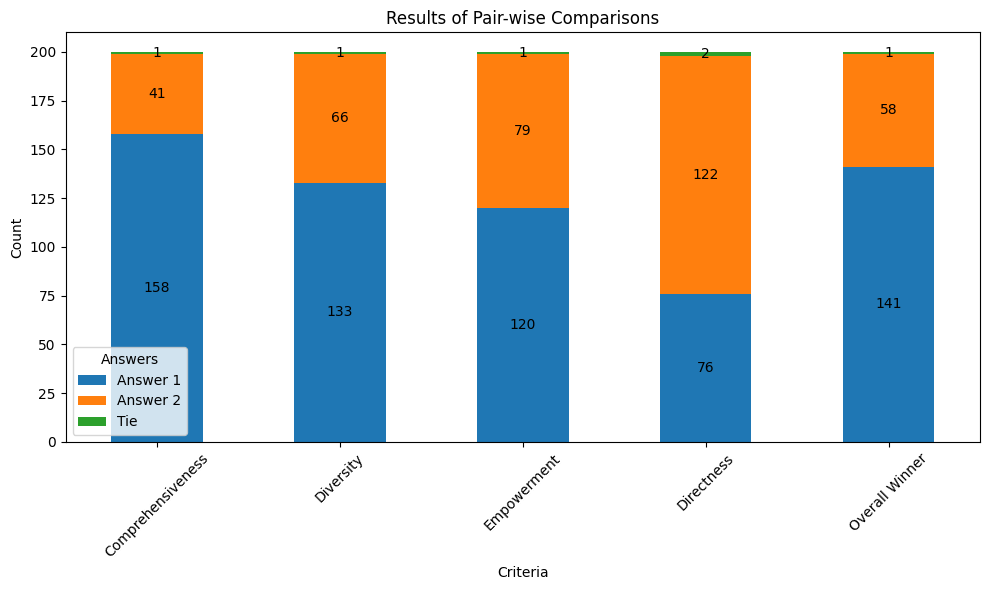

In [120]:
import matplotlib.pyplot as plt
import numpy as np

# Count the number of times Answer 1 and Answer 2 were chosen for each criterion
counts = {
    criterion: target_df[criterion].value_counts()
    for criterion in [
        "comprehensiveness",
        "diversity",
        "empowerment",
        "directness",
        "overall_winner",
    ]
}

# Convert counts into a DataFrame for plotting
count_df = pd.DataFrame(counts).fillna(0)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Create a bar plot
count_df.T.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Results of Pair-wise Comparisons")
ax.set_ylabel("Count")
ax.set_xlabel("Criteria")
ax.legend(title="Answers")
ax.set_xticklabels(
    ["Comprehensiveness", "Diversity", "Empowerment", "Directness", "Overall Winner"],
    rotation=45,
)

# Adding value on top of each bar
for i, bars in enumerate(ax.containers):
    ax.bar_label(bars, label_type="center")

plt.tight_layout()
plt.show()

### Resume analisys

In [121]:
def count_wins(df, answer):
    count_dict = {}
    for column in [
        "comprehensiveness",
        "diversity",
        "empowerment",
        "directness",
        "overall_winner",
    ]:
        count_dict[column] = (df[column] == answer).sum()
    return count_dict


# Count wins for "Answer 1" and "Answer 2"
answer1_wins = count_wins(target_df, "Answer 1")
answer2_wins = count_wins(target_df, "Answer 2")


# Overall stats
def print_analysis():
    print("Analysis of Pair-wise Comparison Results:")
    print("\nTotal comparisons:", len(target_df))
    print("\nAnswer 1 Wins by Criterion:")
    for criterion, count in answer1_wins.items():
        print(f"  {criterion.capitalize()}: {count}")

    print("\nAnswer 2 Wins by Criterion:")
    for criterion, count in answer2_wins.items():
        print(f"  {criterion.capitalize()}: {count}")

    print("\nOverall Strategy Performance:")
    overall_1_wins = target_df[target_df["overall_winner"] == "Answer 1"]
    overall_2_wins = target_df[target_df["overall_winner"] == "Answer 2"]

    strategy_performance = (
        target_df.groupby(["expriment_1_name", "expriment_2_name", "overall_winner"])
        .size()
        .unstack(fill_value=0)
    )
    print(strategy_performance)


print_analysis()

Analysis of Pair-wise Comparison Results:

Total comparisons: 200

Answer 1 Wins by Criterion:
  Comprehensiveness: 158
  Diversity: 133
  Empowerment: 120
  Directness: 76
  Overall_winner: 141

Answer 2 Wins by Criterion:
  Comprehensiveness: 41
  Diversity: 66
  Empowerment: 79
  Directness: 122
  Overall_winner: 58

Overall Strategy Performance:
overall_winner                                       Answer 1  Answer 2  Tie
expriment_1_name          expriment_2_name                                  
LexicalSearch1HopStrategy LexicalSearch0HopStrategy       141        58    1


### Comparacao head-to-head

In [122]:
# Function to calculate the head-to-head scores
def calculate_scores(df):
    # Dictionary to store the results
    results = {}

    # Iterate through the rows and accumulate the scores
    for index, row in df.iterrows():
        exp1 = row["expriment_1_name"]
        exp2 = row["expriment_2_name"]

        if (exp1, exp2) not in results:
            results[(exp1, exp2)] = {"exp1_wins": 0, "exp2_wins": 0}

        # Check who wins more criteria
        criteria = ["comprehensiveness", "diversity", "empowerment", "directness"]
        for criterion in criteria:
            if row[criterion] == "Answer 1":
                results[(exp1, exp2)]["exp1_wins"] += 1
            elif row[criterion] == "Answer 2":
                results[(exp1, exp2)]["exp2_wins"] += 1

    return results


# Calculate scores
comparison_results = calculate_scores(target_df)

# Print the results
for pair, scores in comparison_results.items():
    exp1, exp2 = pair
    print(f"Comparison between {exp1} and {exp2}:")
    print(f" - {exp1} wins: {scores['exp1_wins']} times")
    print(f" - {exp2} wins: {scores['exp2_wins']} times")
    print()

Comparison between LexicalSearch1HopStrategy and LexicalSearch0HopStrategy:
 - LexicalSearch1HopStrategy wins: 487 times
 - LexicalSearch0HopStrategy wins: 308 times



### Vencedor geral

In [123]:
# Function to count wins for each experiment
def calculate_win_rates(df):
    win_rates = {}

    for index, row in df.iterrows():
        exp1 = row["expriment_1_name"]
        exp2 = row["expriment_2_name"]

        if exp1 not in win_rates:
            win_rates[exp1] = 0
        if exp2 not in win_rates:
            win_rates[exp2] = 0

        # Check who won the overall category
        winner = row["overall_winner"]
        if winner == "Answer 1":
            win_rates[exp1] += 1
        elif winner == "Answer 2":
            win_rates[exp2] += 1

    return win_rates


# Calculate the win rates
win_rates = calculate_win_rates(target_df)

# Convert win rates to percentages if needed
total_matches = target_df.shape[0]
win_percentage = {k: (v / total_matches) * 100 for k, v in win_rates.items()}

# Display the results
print("Win Rates (as percentages based on overall winner):")
for experiment, percentage in win_percentage.items():
    print(f"{experiment}: {percentage:.2f}%")

Win Rates (as percentages based on overall winner):
LexicalSearch1HopStrategy: 70.50%
LexicalSearch0HopStrategy: 29.00%


### Vencedor geral - comprehensiveness

In [124]:
# Function to count wins for each experiment
def calculate_win_rates(df):
    win_rates = {}

    for index, row in df.iterrows():
        exp1 = row["expriment_1_name"]
        exp2 = row["expriment_2_name"]

        if exp1 not in win_rates:
            win_rates[exp1] = 0
        if exp2 not in win_rates:
            win_rates[exp2] = 0

        # Check who won the overall category
        winner = row["comprehensiveness"]
        if winner == "Answer 1":
            win_rates[exp1] += 1
        elif winner == "Answer 2":
            win_rates[exp2] += 1

    return win_rates


# Calculate the win rates
win_rates = calculate_win_rates(target_df)

# Convert win rates to percentages if needed
total_matches = target_df.shape[0]
win_percentage = {k: (v / total_matches) * 100 for k, v in win_rates.items()}

# Display the results
print("Win Rates (as percentages based on Comprehensiveness):")
for experiment, percentage in win_percentage.items():
    print(f"{experiment}: {percentage:.2f}%")

Win Rates (as percentages based on Comprehensiveness):
LexicalSearch1HopStrategy: 79.00%
LexicalSearch0HopStrategy: 20.50%


### Vencedor geral - diversity

In [125]:
# Function to count wins for each experiment
def calculate_win_rates(df):
    win_rates = {}

    for index, row in df.iterrows():
        exp1 = row["expriment_1_name"]
        exp2 = row["expriment_2_name"]

        if exp1 not in win_rates:
            win_rates[exp1] = 0
        if exp2 not in win_rates:
            win_rates[exp2] = 0

        # Check who won the overall category
        winner = row["diversity"]
        if winner == "Answer 1":
            win_rates[exp1] += 1
        elif winner == "Answer 2":
            win_rates[exp2] += 1

    return win_rates


# Calculate the win rates
win_rates = calculate_win_rates(target_df)

# Convert win rates to percentages if needed
total_matches = target_df.shape[0]
win_percentage = {k: (v / total_matches) * 100 for k, v in win_rates.items()}

# Display the results
print("Win Rates (as percentages based on Diversity):")
for experiment, percentage in win_percentage.items():
    print(f"{experiment}: {percentage:.2f}%")

Win Rates (as percentages based on Diversity):
LexicalSearch1HopStrategy: 66.50%
LexicalSearch0HopStrategy: 33.00%


### Vencedor geral - empowerment

In [126]:
# Function to count wins for each experiment
def calculate_win_rates(df):
    win_rates = {}

    for index, row in df.iterrows():
        exp1 = row["expriment_1_name"]
        exp2 = row["expriment_2_name"]

        if exp1 not in win_rates:
            win_rates[exp1] = 0
        if exp2 not in win_rates:
            win_rates[exp2] = 0

        # Check who won the overall category
        winner = row["empowerment"]
        if winner == "Answer 1":
            win_rates[exp1] += 1
        elif winner == "Answer 2":
            win_rates[exp2] += 1

    return win_rates


# Calculate the win rates
win_rates = calculate_win_rates(target_df)

# Convert win rates to percentages if needed
total_matches = target_df.shape[0]
win_percentage = {k: (v / total_matches) * 100 for k, v in win_rates.items()}

# Display the results
print("Win Rates (as percentages based on Empowerment):")
for experiment, percentage in win_percentage.items():
    print(f"{experiment}: {percentage:.2f}%")

Win Rates (as percentages based on Empowerment):
LexicalSearch1HopStrategy: 60.00%
LexicalSearch0HopStrategy: 39.50%


### Vencedor geral - Directness

In [127]:
# Function to count wins for each experiment
def calculate_win_rates(df):
    win_rates = {}

    for index, row in df.iterrows():
        exp1 = row["expriment_1_name"]
        exp2 = row["expriment_2_name"]

        if exp1 not in win_rates:
            win_rates[exp1] = 0
        if exp2 not in win_rates:
            win_rates[exp2] = 0

        # Check who won the overall category
        winner = row["directness"]
        if winner == "Answer 1":
            win_rates[exp1] += 1
        elif winner == "Answer 2":
            win_rates[exp2] += 1

    return win_rates


# Calculate the win rates
win_rates = calculate_win_rates(target_df)

# Convert win rates to percentages if needed
total_matches = target_df.shape[0]
win_percentage = {k: (v / total_matches) * 100 for k, v in win_rates.items()}

# Display the results
print("Win Rates (as percentages based on Directness):")
for experiment, percentage in win_percentage.items():
    print(f"{experiment}: {percentage:.2f}%")

Win Rates (as percentages based on Directness):
LexicalSearch1HopStrategy: 38.00%
LexicalSearch0HopStrategy: 61.00%


### Vencedor geral - Overall winner

In [128]:
# Function to count wins for each experiment
def calculate_win_rates(df):
    win_rates = {}

    for index, row in df.iterrows():
        exp1 = row["expriment_1_name"]
        exp2 = row["expriment_2_name"]

        if exp1 not in win_rates:
            win_rates[exp1] = 0
        if exp2 not in win_rates:
            win_rates[exp2] = 0

        # Check who won the overall category
        winner = row["overall_winner"]
        if winner == "Answer 1":
            win_rates[exp1] += 1
        elif winner == "Answer 2":
            win_rates[exp2] += 1

    return win_rates


# Calculate the win rates
win_rates = calculate_win_rates(target_df)

# Convert win rates to percentages if needed
total_matches = target_df.shape[0]
win_percentage = {k: (v / total_matches) * 100 for k, v in win_rates.items()}

# Display the results
print("Win Rates (as percentages based on Overall winner):")
for experiment, percentage in win_percentage.items():
    print(f"{experiment}: {percentage:.2f}%")

Win Rates (as percentages based on Overall winner):
LexicalSearch1HopStrategy: 70.50%
LexicalSearch0HopStrategy: 29.00%


### Matrix comparacao

In [129]:
columns_test = [
    "LexicalSearch0HopStrategy",
    "LexicalSearch1HopStrategy",
]

pd.DataFrame(index=columns_test, columns=columns_test, data=0)

,LexicalSearch0HopStrategy,LexicalSearch1HopStrategy
LexicalSearch0HopStrategy,0,0
LexicalSearch1HopStrategy,0,0


In [130]:
columns_test = [
    "SimilaritySearch0HopStrategy",
    "SimilaritySearch1HopStrategy",
]

pd.DataFrame(index=columns_test, columns=columns_test, data=0)

,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy
SimilaritySearch0HopStrategy,0,0
SimilaritySearch1HopStrategy,0,0


In [131]:
columns_test = [
    "SimilaritySearch0HopStrategy",
    "SimilaritySearch1HopStrategy",
    "LexicalSearch0HopStrategy",
    "LexicalSearch1HopStrategy",
]

pd.DataFrame(index=columns_test, columns=columns_test, data=0)

,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,LexicalSearch0HopStrategy,LexicalSearch1HopStrategy
SimilaritySearch0HopStrategy,0,0,0,0
SimilaritySearch1HopStrategy,0,0,0,0
LexicalSearch0HopStrategy,0,0,0,0
LexicalSearch1HopStrategy,0,0,0,0


#### Comprehensiveness

In [132]:
# Initialize an empty dataframe to hold the comparison matrix
comparison_matrix = pd.DataFrame(index=columns_test, columns=columns_test, data=0)

# Criteria to compare
criteria = ["comprehensiveness"]

# Compute the pairwise comparison
for index, row in target_df.iterrows():
    exp1 = row["expriment_1_name"]
    exp2 = row["expriment_2_name"]

    # Calculate scores based on which answer won per criterion
    exp1_score = sum(1 for criterion in criteria if row[criterion] == "Answer 1")
    exp2_score = sum(1 for criterion in criteria if row[criterion] == "Answer 2")

    # Update matrix based on scores, adding to the current value
    comparison_matrix.at[exp1, exp2] += exp2_score
    comparison_matrix.at[exp2, exp1] += exp1_score

# Fill diagonal with NaN because comparing the same experiment yields no information
# np.fill_diagonal(comparison_matrix.values, np.nan)

comparison_matrix

,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,LexicalSearch0HopStrategy,LexicalSearch1HopStrategy
SimilaritySearch0HopStrategy,0,0,0,0
SimilaritySearch1HopStrategy,0,0,0,0
LexicalSearch0HopStrategy,0,0,0,158
LexicalSearch1HopStrategy,0,0,41,0


In [133]:
comparison_matrix.to_dict()

{'SimilaritySearch0HopStrategy': {'SimilaritySearch0HopStrategy': 0,
  'SimilaritySearch1HopStrategy': 0,
  'LexicalSearch0HopStrategy': 0,
  'LexicalSearch1HopStrategy': 0},
 'SimilaritySearch1HopStrategy': {'SimilaritySearch0HopStrategy': 0,
  'SimilaritySearch1HopStrategy': 0,
  'LexicalSearch0HopStrategy': 0,
  'LexicalSearch1HopStrategy': 0},
 'LexicalSearch0HopStrategy': {'SimilaritySearch0HopStrategy': 0,
  'SimilaritySearch1HopStrategy': 0,
  'LexicalSearch0HopStrategy': 0,
  'LexicalSearch1HopStrategy': 41},
 'LexicalSearch1HopStrategy': {'SimilaritySearch0HopStrategy': 0,
  'SimilaritySearch1HopStrategy': 0,
  'LexicalSearch0HopStrategy': 158,
  'LexicalSearch1HopStrategy': 0}}

#### All

In [134]:
# Initialize an empty dataframe to hold the comparison matrix
comparison_matrix = pd.DataFrame(index=columns_test, columns=columns_test, data=0)

# Criteria to compare
criteria = [
    "comprehensiveness",
    "diversity",
    "empowerment",
    "directness",
    "overall_winner",
]

# Compute the pairwise comparison
for index, row in target_df.iterrows():
    exp1 = row["expriment_1_name"]
    exp2 = row["expriment_2_name"]

    # Calculate scores based on which answer won per criterion
    exp1_score = sum([1 for criterion in criteria if row[criterion] == "Answer 1"])
    exp2_score = sum([1 for criterion in criteria if row[criterion] == "Answer 2"])

    # Update matrix based on scores, adding to the current value
    comparison_matrix.at[exp1, exp2] += exp2_score
    comparison_matrix.at[exp2, exp1] += exp1_score

# Fill diagonal with NaN because comparing the same experiment yields no information
# np.fill_diagonal(comparison_matrix.values, np.nan)

comparison_matrix

,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,LexicalSearch0HopStrategy,LexicalSearch1HopStrategy
SimilaritySearch0HopStrategy,0,0,0,0
SimilaritySearch1HopStrategy,0,0,0,0
LexicalSearch0HopStrategy,0,0,0,628
LexicalSearch1HopStrategy,0,0,366,0


In [135]:
comparison_matrix.to_dict()

{'SimilaritySearch0HopStrategy': {'SimilaritySearch0HopStrategy': 0,
  'SimilaritySearch1HopStrategy': 0,
  'LexicalSearch0HopStrategy': 0,
  'LexicalSearch1HopStrategy': 0},
 'SimilaritySearch1HopStrategy': {'SimilaritySearch0HopStrategy': 0,
  'SimilaritySearch1HopStrategy': 0,
  'LexicalSearch0HopStrategy': 0,
  'LexicalSearch1HopStrategy': 0},
 'LexicalSearch0HopStrategy': {'SimilaritySearch0HopStrategy': 0,
  'SimilaritySearch1HopStrategy': 0,
  'LexicalSearch0HopStrategy': 0,
  'LexicalSearch1HopStrategy': 366},
 'LexicalSearch1HopStrategy': {'SimilaritySearch0HopStrategy': 0,
  'SimilaritySearch1HopStrategy': 0,
  'LexicalSearch0HopStrategy': 628,
  'LexicalSearch1HopStrategy': 0}}

#### Resumo geral

In [136]:
import numpy as np

In [137]:
# Initialize a DataFrame to hold the pairwise scores
experiments = np.unique(target_df[["expriment_1_name", "expriment_2_name"]].values)
pairwise_matrix = pd.DataFrame(0, index=experiments, columns=experiments)


# Function to update the pairwise matrix
def update_scores(row):
    criteria = [
        "comprehensiveness",
        "diversity",
        "empowerment",
        "directness",
        "overall_winner",
    ]

    for criterion in criteria:
        answer1 = "Answer 1"
        answer2 = "Answer 2"

        if row[criterion] == answer1:
            pairwise_matrix.loc[row["expriment_1_name"], row["expriment_2_name"]] += 1
        elif row[criterion] == answer2:
            pairwise_matrix.loc[row["expriment_2_name"], row["expriment_1_name"]] += 1


# Iterate over each row in the DataFrame and update scores accordingly
target_df.apply(update_scores, axis=1)

# Display the resulting pairwise comparison matrix
print("Pairwise comparison matrix:")
print(pairwise_matrix)

# Calculate rankings: count of criteria won over alternative strategies
total_wins = pairwise_matrix.sum(axis=1)
rankings = total_wins.rank(ascending=False)

print("\nTotal wins by each experiment strategy:")
print(total_wins)

print("\nRanking of each experiment strategy:")
print(rankings)

Pairwise comparison matrix:
                           LexicalSearch0HopStrategy  \
LexicalSearch0HopStrategy                          0   
LexicalSearch1HopStrategy                        628   

                           LexicalSearch1HopStrategy  
LexicalSearch0HopStrategy                        366  
LexicalSearch1HopStrategy                          0  

Total wins by each experiment strategy:
LexicalSearch0HopStrategy    366
LexicalSearch1HopStrategy    628
dtype: int64

Ranking of each experiment strategy:
LexicalSearch0HopStrategy    2.0
LexicalSearch1HopStrategy    1.0
dtype: float64


# Overall analisys per question BRACIS

In [167]:
target_df.columns

Index(['consumer_id', 'experiment_1', 'experiment_2', 'expriment_1_name',
       'expriment_2_name', 'model_evaluation', 'response', 'comprehensiveness',
       'diversity', 'empowerment', 'directness', 'overall_winner', 'question',
       'model', 'search_type'],
      dtype='object')

In [168]:
experiments_name = np.unique(target_df[["experiment_1", "experiment_2"]].values)

In [169]:
questions = ()

In [170]:
list_question = list(set([expertiment.split(":")[0] for expertiment in experiments_name]))

In [171]:
list_question.sort()

In [172]:
target_df.loc[target_df["experiment_1"].str.contains(list_question[0])]

,consumer_id,experiment_1,experiment_2,expriment_1_name,expriment_2_name,model_evaluation,response,comprehensiveness,diversity,empowerment,directness,overall_winner,question,model,search_type
44,Milton509_Ortiz186_d66b5418-06cb-fc8a-8c13-856...,Q1:llama-3-70b-instruct-awq:similarity_search_...,Q1:llama-3-70b-instruct-awq:similarity_search_...,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,"{'Comprehensiveness': {'Winner': 'Answer 1', '...","content='```json\n{\n ""Comprehensiveness"": ...",Answer 1,Answer 2,Answer 2,Answer 1,Answer 2,Q1,llama-3-70b-instruct-awq,similarity_search_0_hop
94,Jacklyn830_Veum823_e0e1f21a-22a7-d166-7bb1-63f...,Q1:gemini-1.5-pro:similarity_search_0_hop,Q1:gemini-1.5-pro:similarity_search_1_hop,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,"{'Comprehensiveness': {'Winner': 'Answer 1', '...","content='```json\n{\n ""Comprehensiveness"": ...",Answer 1,Answer 2,Answer 2,Answer 2,Answer 2,Q1,gemini-1.5-pro,similarity_search_0_hop
140,Beatris270_Bogan287_5b3645de-a2d0-d016-0839-ba...,Q1:anthropic.claude-v3-opus:similarity_search_...,Q1:anthropic.claude-v3-opus:similarity_search_...,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,"{'Comprehensiveness': {'Winner': 'Answer 1', '...","content='{\n ""Comprehensiveness"": {\n ...",Answer 1,Answer 1,Answer 1,Answer 2,Answer 1,Q1,anthropic.claude-v3-opus,similarity_search_0_hop
190,Edythe31_Morar593_9c3df38a-d3b7-2198-3898-51f9...,Q1:gemini-1.5-pro:similarity_search_0_hop,Q1:gemini-1.5-pro:similarity_search_1_hop,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,"{'Comprehensiveness': {'Winner': 'Answer 1', '...","content='```json\n{\n ""Comprehensiveness"": ...",Answer 1,Answer 2,Answer 2,Answer 2,Answer 2,Q1,gemini-1.5-pro,similarity_search_0_hop
236,Beatris270_Bogan287_5b3645de-a2d0-d016-0839-ba...,Q1:gpt-4o-2024-08-06:similarity_search_0_hop,Q1:gpt-4o-2024-08-06:similarity_search_1_hop,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,"{'Comprehensiveness': {'Winner': 'Answer 2', '...","content='```json\n{\n ""Comprehensiveness"": ...",Answer 2,Answer 2,Answer 1,Answer 1,Answer 1,Q1,gpt-4o-2024-08-06,similarity_search_0_hop
284,Jacklyn830_Veum823_e0e1f21a-22a7-d166-7bb1-63f...,Q1:gpt-4o-2024-08-06:similarity_search_0_hop,Q1:gpt-4o-2024-08-06:similarity_search_1_hop,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,"{'Comprehensiveness': {'Winner': 'Answer 2', '...","content='```json\n{\n ""Comprehensiveness"": ...",Answer 2,Answer 2,Answer 2,Answer 1,Answer 2,Q1,gpt-4o-2024-08-06,similarity_search_0_hop
332,Jacklyn830_Veum823_e0e1f21a-22a7-d166-7bb1-63f...,Q1:DeepSeek-R1-Distill-Llama-70B-FP8:similarit...,Q1:DeepSeek-R1-Distill-Llama-70B-FP8:similarit...,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,"{'Comprehensiveness': {'Winner': 'Answer 1', '...","content='```json\n{\n ""Comprehensiveness"": ...",Answer 1,Answer 1,Answer 1,Answer 2,Answer 1,Q1,DeepSeek-R1-Distill-Llama-70B-FP8,similarity_search_0_hop
380,Jacklyn830_Veum823_e0e1f21a-22a7-d166-7bb1-63f...,Q1:llama-3-70b-instruct-awq:similarity_search_...,Q1:llama-3-70b-instruct-awq:similarity_search_...,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,"{'Comprehensiveness': {'Winner': 'Answer 1', '...","content='```json\n{\n ""Comprehensiveness"": ...",Answer 1,Answer 1,Answer 1,Answer 1,Answer 1,Q1,llama-3-70b-instruct-awq,similarity_search_0_hop
428,Allen322_Ferry570_ad134528-56a5-35fd-c37f-466f...,Q1:DeepSeek-R1-Distill-Llama-70B-FP8:similarit...,Q1:DeepSeek-R1-Distill-Llama-70B-FP8:similarit...,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,"{'Comprehensiveness': {'Winner': 'Answer 1', '...","content='```json\n{\n ""Comprehensiveness"": ...",Answer 1,Answer 2,Answer 1,Answer 1,Answer 1,Q1,DeepSeek-R1-Distill-Llama-70B-FP8,similarity_search_0_hop
476,Beatris270_Bogan287_5b3645de-a2d0-d016-0839-ba...,Q1:DeepSeek-R1-Distill-Llama-70B-FP8:similarit...,Q1:DeepSeek-R1-Distill-Llama-70B-FP8:similarit...,SimilaritySearch0HopS

In [173]:
# Function to update the pairwise matrix
def analys_by_question(list_question, target_df):
    def update_scores(row):
        criteria = [
            "comprehensiveness",
            "diversity",
            "empowerment",
            "directness",
            "overall_winner",
        ]

        for criterion in criteria:
            answer1 = "Answer 1"
            answer2 = "Answer 2"

            if row[criterion] == answer1:
                pairwise_matrix.loc[row["expriment_1_name"], row["expriment_2_name"]] += 1
            elif row[criterion] == answer2:
                pairwise_matrix.loc[row["expriment_2_name"], row["expriment_1_name"]] += 1

    # Iterate over each row in the DataFrame and update scores accordingly

    for question in list_question:
        print(f"Start analysis for question: {question}")
        # Initialize a DataFrame to hold the pairwise scores
        experiments = np.unique(
            target_df[["expriment_1_name", "expriment_2_name"]].values
        )
        pairwise_matrix = pd.DataFrame(0, index=experiments, columns=experiments)

        df_question = target_df.loc[target_df["experiment_1"].str.contains(question)]

        df_question.apply(update_scores, axis=1)

        # Display the resulting pairwise comparison matrix
        #print(f"Pairwise comparison matrix for question number {question}:")
        #print(pairwise_matrix)

        # Calculate rankings: count of criteria won over alternative strategies
        total_wins = pairwise_matrix.sum(axis=1)
        rankings = total_wins.rank(ascending=False)

        print(f"\nTotal wins by each experiment strategy for question number {question}:")
        print(total_wins)

        #print(f"\nRanking of each experiment strategy for question number {question}:")
        #print(rankings)

        total = total_wins.sum()
        proportions = total_wins / total
        print(f"\Proportions of each experiment strategy for model: {question}")
        print(proportions)
        print(f"Finish analysis for question: {question}\n\n\n\n")


analys_by_question(list_question, target_df)

Start analysis for question: Q1

Total wins by each experiment strategy for question number Q1:
SimilaritySearch0HopStrategy    57
SimilaritySearch1HopStrategy    68
dtype: int64
\Proportions of each experiment strategy for model: Q1
SimilaritySearch0HopStrategy    0.456
SimilaritySearch1HopStrategy    0.544
dtype: float64
Finish analysis for question: Q1




Start analysis for question: Q2

Total wins by each experiment strategy for question number Q2:
SimilaritySearch0HopStrategy    56
SimilaritySearch1HopStrategy    18
dtype: int64
\Proportions of each experiment strategy for model: Q2
SimilaritySearch0HopStrategy    0.756757
SimilaritySearch1HopStrategy    0.243243
dtype: float64
Finish analysis for question: Q2




Start analysis for question: Q3

Total wins by each experiment strategy for question number Q3:
SimilaritySearch0HopStrategy    30
SimilaritySearch1HopStrategy    95
dtype: int64
\Proportions of each experiment strategy for model: Q3
SimilaritySearch0HopStrategy    0.24

In [174]:
# Function to update the pairwise matrix
def analys_by_model(list_question, list_metrics, target_df):
    def update_scores(row, criterion):
        answer1 = "Answer 1"
        answer2 = "Answer 2"

        if row[criterion] == answer1:
            pairwise_matrix.loc[row["expriment_1_name"], row["expriment_2_name"]] += 1
        elif row[criterion] == answer2:
            pairwise_matrix.loc[row["expriment_2_name"], row["expriment_1_name"]] += 1

    # Iterate over each row in the DataFrame and update scores accordingly
    total_proportions_by_question = {}
    for question in list_question:
        print(f"Start analysis for question: {question}")
        total_proportions_by_metric = {}
        for metric in list_metrics:
            print(f"Start analysis for metric: {metric}")
            # Initialize a DataFrame to hold the pairwise scores
            experiments = np.unique(
                target_df[["expriment_1_name", "expriment_2_name"]].values
            )
            pairwise_matrix = pd.DataFrame(0, index=experiments, columns=experiments)
    
            df_model_metric = target_df.loc[target_df["experiment_1"].str.contains(question)]
    
            df_model_metric.apply(update_scores, criterion=metric, axis=1)
    
            # Display the resulting pairwise comparison matrix
            #print(f"Pairwise comparison matrix for model {metric}:")
            #print(pairwise_matrix)
    
            # Calculate rankings: count of criteria won over alternative strategies
            total_wins = pairwise_matrix.sum(axis=1)
            rankings = total_wins.rank(ascending=False)
    
            print(f"\nTotal wins by each experiment strategy metric: {metric}")
            print(total_wins)
    
            #print(f"\nRanking of each experiment strategy for metric: {metric}")
            #print(rankings)
    
            total = total_wins.sum()
            proportions = total_wins / total
            print(f"Proportions of each experiment strategy for metric: {metric}")
            print(proportions)
            
            print(f"Finish analysis for metric: {metric}\n")
            total_proportions_by_metric.update({metric: proportions})
        print(f"Finish analysis for model: {question}\n\n")
        total_proportions_by_question.update({question: total_proportions_by_metric})
    return total_proportions_by_question

list_metric = [
            "comprehensiveness",
            "diversity",
            "empowerment",
            "directness",
            "overall_winner",
        ]


total_wins = analys_by_model(list_question, list_metric, target_df)

Start analysis for question: Q1
Start analysis for metric: comprehensiveness

Total wins by each experiment strategy metric: comprehensiveness
SimilaritySearch0HopStrategy    15
SimilaritySearch1HopStrategy    10
dtype: int64
Proportions of each experiment strategy for metric: comprehensiveness
SimilaritySearch0HopStrategy    0.6
SimilaritySearch1HopStrategy    0.4
dtype: float64
Finish analysis for metric: comprehensiveness

Start analysis for metric: diversity

Total wins by each experiment strategy metric: diversity
SimilaritySearch0HopStrategy     9
SimilaritySearch1HopStrategy    16
dtype: int64
Proportions of each experiment strategy for metric: diversity
SimilaritySearch0HopStrategy    0.36
SimilaritySearch1HopStrategy    0.64
dtype: float64
Finish analysis for metric: diversity

Start analysis for metric: empowerment

Total wins by each experiment strategy metric: empowerment
SimilaritySearch0HopStrategy    11
SimilaritySearch1HopStrategy    14
dtype: int64
Proportions of each 

# Comparing 0-Hop (L0) and 1-Hop (L1) Strategies per Question

### Question: Q1 - What are my current medications, and how should I take them?

| Metric            | LexicalSearch0HopStrategy (L0) | LexicalSearch1HopStrategy (L1) |
|-------------------|---------------------------------|---------------------------------|
| Comprehensiveness | 0.20                            | **0.80** |
| Diversity         | 0.20                            | **0.80** |
| Empowerment       | 0.24                            | **0.76** |
| Directness        | **0.56** | 0.44                            |
| Overall Winner    | 0.28                            | **0.72** |

### Question: Q2 - What are my documented allergies, and how severe are they?

| Metric            | LexicalSearch0HopStrategy (L0) | LexicalSearch1HopStrategy (L1) |
|-------------------|---------------------------------|---------------------------------|
| Comprehensiveness | 0.33                            | **0.67** |
| Diversity         | 0.33                            | **0.67** |
| Empowerment       | 0.33                            | **0.67** |
| Directness        | 0.46                            | **0.54** |
| Overall Winner    | 0.33                            | **0.67** |

### Question: Q3 - Can you summarize my current medical conditions?

| Metric            | LexicalSearch0HopStrategy (L0) | LexicalSearch1HopStrategy (L1) |
|-------------------|---------------------------------|---------------------------------|
| Comprehensiveness | 0.12                            | **0.88** |
| Diversity         | 0.40                            | **0.60** |
| Empowerment       | 0.44                            | **0.56** |
| Directness        | **0.80** | 0.20                            |
| Overall Winner    | 0.36                            | **0.64** |

### Question: Q4 - What are my recent laboratory values, what do they mean, and how can I improve them?

| Metric            | LexicalSearch0HopStrategy (L0) | LexicalSearch1HopStrategy (L1) |
|-------------------|---------------------------------|---------------------------------|
| Comprehensiveness | 0.32                            | **0.68** |
| Diversity         | 0.28                            | **0.72** |
| Empowerment       | 0.24                            | **0.76** |
| Directness        | 0.20                            | **0.80** |
| Overall Winner    | 0.24                            | **0.76** |

### Question: Q5 - Can you summarize my care plan history?

| Metric            | LexicalSearch0HopStrategy (L0) | LexicalSearch1HopStrategy (L1) |
|-------------------|---------------------------------|---------------------------------|
| Comprehensiveness | 0.08                            | **0.92** |
| Diversity         | 0.12                            | **0.88** |
| Empowerment       | 0.24                            | **0.76** |
| Directness        | **0.80** | 0.20                            |
| Overall Winner    | 0.16                            | **0.84** |

### Question: Q6 - Can you provide a breakdown of my medical bills?

| Metric            | LexicalSearch0HopStrategy (L0) | LexicalSearch1HopStrategy (L1) |
|-------------------|---------------------------------|---------------------------------|
| Comprehensiveness | 0.24                            | **0.76** |
| Diversity         | **0.56** | 0.44                            |
| Empowerment       | 0.48                            | **0.52** |
| Directness        | 0.48                            | **0.52** |
| Overall Winner    | 0.32                            | **0.68** |

### Question: Q7 - What procedures have I undergone recently, and what were the outcomes?

| Metric            | LexicalSearch0HopStrategy (L0) | LexicalSearch1HopStrategy (L1) |
|-------------------|---------------------------------|---------------------------------|
| Comprehensiveness | 0.20                            | **0.80** |
| Diversity         | 0.32                            | **0.68** |
| Empowerment       | **0.52** | 0.48                            |
| Directness        | **0.80** | 0.20                            |
| Overall Winner    | 0.32                            | **0.68** |

### Question: Q8 - Can you summarize my immunization history?

| Metric            | LexicalSearch0HopStrategy (L0) | LexicalSearch1HopStrategy (L1) |
|-------------------|---------------------------------|---------------------------------|
| Comprehensiveness | 0.16                            | **0.84** |
| Diversity         | 0.44                            | **0.56** |
| Empowerment       | **0.68** | 0.32                            |
| Directness        | **0.83** | 0.17                            |
| Overall Winner    | 0.32                            | **0.68** |

## Overall Trend

**Key Finding:** LexicalSearch1HopStrategy (L1) generally outperformed LexicalSearch0HopStrategy (L0)

* L1 explores one degree of connection in the knowledge graph.
* This often leads to more beneficial responses for patients across the metrics.

---

## Comprehensiveness

**L1 Shows Superior Comprehensiveness**

* L1 consistently outperformed L0 across *all* questions for comprehensiveness.
* **Examples:**
    * Q3 ("Summarize my current medical conditions?"): L1 win proportion = 0.88
    * Q5 ("Summarize my care plan history?"): L1 win proportion = 0.92
* **Implication:** Considering related concepts provides more complete and informative answers.

---

## Diversity

**L1 Offers More Diverse Information**

* For all questions, L1 achieved a higher or equal number of wins compared to L0 in diversity.
* **Benefit:** Exploring connected information provides a wider range of relevant information.
* This can address different facets of the patient's query and offer a more nuanced understanding.

---

##  Empowerment

**L1 Generally Leads to More Empowering Responses**

* The metric of empowerment generally favored L1.
* While L0 showed some competition (e.g., Q8), L1 was generally better.
* **Reasoning:** Accessing slightly more contextual information better supports patient autonomy and decision-making.

---

## Directness - A Different Pattern**

**L0 Shows Strength in Directness for Specific Questions**

* In several questions, L0 had more wins for directness:
    * Q3 ("Summarize my current medical conditions?")
    * Q5 ("Summarize my care plan history?")
    * Q7 ("What procedures have I undergone recently?")
    * Q8 ("Summarize my immunization history?")
* **Interpretation:** Direct lexical search can yield more straightforward answers for certain queries.
* **Trade-off:** L0 often falls short in comprehensiveness, diversity, and empowerment.

---

## Overall Winner

**L1 Emerges as the Preferred Strategy Overall**

* Considering the overall winner metric (aggregating performance), L1 was preferred for most questions.
* **Conclusion:** Exploring one hop provides a better balance across the evaluated dimensions.
* This leads to more satisfactory answers for patients on average.

# Comparing 0-Hop (S0) and 1-Hop (S1) Strategies per Question

### Question: Q1 - What are my current medications, and how should I take them?

| Metric            | SimilaritySearch0HopStrategy (S0) | SimilaritySearch1HopStrategy (S1) |
|-------------------|------------------------------------|------------------------------------|
| Comprehensiveness | **0.60** | 0.40                               |
| Diversity         | 0.36                               | **0.64** |
| Empowerment       | 0.44                               | **0.56** |
| Directness        | 0.44                               | **0.56** |
| Overall Winner    | 0.44                               | **0.56** |

### Question: Q2 - What are my documented allergies, and how severe are they?

| Metric            | SimilaritySearch0HopStrategy (S0) | SimilaritySearch1HopStrategy (S1) |
|-------------------|------------------------------------|------------------------------------|
| Comprehensiveness | **0.80** | 0.20                               |
| Diversity         | **0.857** | 0.143                              |
| Empowerment       | **0.667** | 0.333                              |
| Directness        | **0.733** | 0.267                              |
| Overall Winner    | **0.733** | 0.267                              |

### Question: Q3 - Can you summarize my current medical conditions?

| Metric            | SimilaritySearch0HopStrategy (S0) | SimilaritySearch1HopStrategy (S1) |
|-------------------|------------------------------------|------------------------------------|
| Comprehensiveness | 0.20                               | **0.80** |
| Diversity         | 0.16                               | **0.84** |
| Empowerment       | 0.16                               | **0.84** |
| Directness        | **0.52** | 0.48                               |
| Overall Winner    | 0.16                               | **0.84** |

### Question: Q4 - What are my recent laboratory values, what do they mean, and how can I improve them?

| Metric            | SimilaritySearch0HopStrategy (S0) | SimilaritySearch1HopStrategy (S1) |
|-------------------|------------------------------------|------------------------------------|
| Comprehensiveness | 0.32                               | **0.68** |
| Diversity         | 0.44                               | **0.56** |
| Empowerment       | 0.20                               | **0.80** |
| Directness        | 0.08                               | **0.92** |
| Overall Winner    | 0.24                               | **0.76** |

### Question: Q5 - Can you summarize my care plan history?

| Metric            | SimilaritySearch0HopStrategy (S0) | SimilaritySearch1HopStrategy (S1) |
|-------------------|------------------------------------|------------------------------------|
| Comprehensiveness | 0.40                               | **0.60** |
| Diversity         | 0.40                               | **0.60** |
| Empowerment       | 0.40                               | **0.60** |
| Directness        | 0.44                               | **0.56** |
| Overall Winner    | 0.40                               | **0.60** |

### Question: Q6 - Can you provide a breakdown of my medical bills?

| Metric            | SimilaritySearch0HopStrategy (S0) | SimilaritySearch1HopStrategy (S1) |
|-------------------|------------------------------------|------------------------------------|
| Comprehensiveness | **0.56** | 0.44                               |
| Diversity         | **0.52** | 0.48                               |
| Empowerment       | **0.56** | 0.44                               |
| Directness        | 0.24                               | **0.76** |
| Overall Winner    | **0.56** | 0.44                               |

### Question: Q7 - What procedures have I undergone recently, and what were the outcomes?

| Metric            | SimilaritySearch0HopStrategy (S0) | SimilaritySearch1HopStrategy (S1) |
|-------------------|------------------------------------|------------------------------------|
| Comprehensiveness | 0.36                               | **0.64** |
| Diversity         | 0.32                               | **0.68** |
| Empowerment       | 0.32                               | **0.68** |
| Directness        | **0.72** | 0.28                               |
| Overall Winner    | 0.28                               | **0.72** |

### Question: Q8 - Can you summarize my immunization history?

| Metric            | SimilaritySearch0HopStrategy (S0) | SimilaritySearch1HopStrategy (S1) |
|-------------------|------------------------------------|------------------------------------|
| Comprehensiveness | 0.40                               | **0.60** |
| Diversity         | 0.24                               | **0.76** |
| Empowerment       | **0.56** | 0.44                               |
| Directness        | **0.60** | 0.40                               |
| Overall Winner    | 0.40                               | **0.60** |

# Overall analisys per patient BRACIS

In [100]:
target_df.columns

Index(['consumer_id', 'experiment_1', 'experiment_2', 'expriment_1_name',
       'expriment_2_name', 'model_evaluation', 'response', 'comprehensiveness',
       'diversity', 'empowerment', 'directness', 'overall_winner', 'question',
       'model', 'search_type'],
      dtype='object')

In [101]:
experiments_name = np.unique(target_df[["experiment_1", "experiment_2"]].values)

In [102]:
patients = ()

In [103]:
list_patient = list(target_df["consumer_id"].unique())

In [104]:
list_patient.sort()

In [151]:
# Function to update the pairwise matrix
def analys_by_patient(list_patient, target_df):
    def update_scores(row):
        criteria = [
            "comprehensiveness",
            "diversity",
            "empowerment",
            "directness",
            "overall_winner",
        ]

        for criterion in criteria:
            answer1 = "Answer 1"
            answer2 = "Answer 2"

            if row[criterion] == answer1:
                pairwise_matrix.loc[row["expriment_1_name"], row["expriment_2_name"]] += 1
            elif row[criterion] == answer2:
                pairwise_matrix.loc[row["expriment_2_name"], row["expriment_1_name"]] += 1

    # Iterate over each row in the DataFrame and update scores accordingly

    for patient in list_patient:
        print(f"Start analysis for question: {patient}")
        # Initialize a DataFrame to hold the pairwise scores
        experiments = np.unique(
            target_df[["expriment_1_name", "expriment_2_name"]].values
        )
        pairwise_matrix = pd.DataFrame(0, index=experiments, columns=experiments)

        df_patient = target_df.loc[target_df["consumer_id"].str.contains(patient)]

        df_patient.apply(update_scores, axis=1)

        # Display the resulting pairwise comparison matrix
        print(f"Pairwise comparison matrix for question number {patient}:")
        print(pairwise_matrix)

        # Calculate rankings: count of criteria won over alternative strategies
        total_wins = pairwise_matrix.sum(axis=1)
        rankings = total_wins.rank(ascending=False)

        print(f"\nTotal wins by each experiment strategy for question number {patient}:")
        print(total_wins)

        print(f"\nRanking of each experiment strategy for question number {patient}:")
        print(rankings)

        total = total_wins.sum()
        proportions = total_wins / total
        print(f"\Proportions of each experiment strategy for model: {patient}")
        print(proportions)
        print()
        print(f"Finish analysis for question: {patient}\n\n\n\n")


analys_by_patient(list_patient, target_df)

Start analysis for question: Allen322_Ferry570_ad134528-56a5-35fd-c37f-466ff119c625
Pairwise comparison matrix for question number Allen322_Ferry570_ad134528-56a5-35fd-c37f-466ff119c625:
                           LexicalSearch0HopStrategy  \
LexicalSearch0HopStrategy                          0   
LexicalSearch1HopStrategy                        113   

                           LexicalSearch1HopStrategy  
LexicalSearch0HopStrategy                         86  
LexicalSearch1HopStrategy                          0  

Total wins by each experiment strategy for question number Allen322_Ferry570_ad134528-56a5-35fd-c37f-466ff119c625:
LexicalSearch0HopStrategy     86
LexicalSearch1HopStrategy    113
dtype: int64

Ranking of each experiment strategy for question number Allen322_Ferry570_ad134528-56a5-35fd-c37f-466ff119c625:
LexicalSearch0HopStrategy    2.0
LexicalSearch1HopStrategy    1.0
dtype: float64
\Proportions of each experiment strategy for model: Allen322_Ferry570_ad134528-56a5-35fd-c

In [152]:
# Function to update the pairwise matrix
def analys_by_model(list_patient, list_metrics, target_df):
    def update_scores(row, criterion):
        answer1 = "Answer 1"
        answer2 = "Answer 2"

        if row[criterion] == answer1:
            pairwise_matrix.loc[row["expriment_1_name"], row["expriment_2_name"]] += 1
        elif row[criterion] == answer2:
            pairwise_matrix.loc[row["expriment_2_name"], row["expriment_1_name"]] += 1

    # Iterate over each row in the DataFrame and update scores accordingly
    total_proportions_by_patient = {}
    for patient in list_patient:
        print(f"Start analysis for patient: {patient}")
        total_proportions_by_metric = {}
        for metric in list_metrics:
            print(f"Start analysis for metric: {metric}")
            # Initialize a DataFrame to hold the pairwise scores
            experiments = np.unique(
                target_df[["expriment_1_name", "expriment_2_name"]].values
            )
            pairwise_matrix = pd.DataFrame(0, index=experiments, columns=experiments)
    
            df_model_metric = target_df.loc[target_df["consumer_id"].str.contains(patient)]
    
            df_model_metric.apply(update_scores, criterion=metric, axis=1)
    
            # Display the resulting pairwise comparison matrix
            #print(f"Pairwise comparison matrix for model {metric}:")
            #print(pairwise_matrix)
    
            # Calculate rankings: count of criteria won over alternative strategies
            total_wins = pairwise_matrix.sum(axis=1)
            rankings = total_wins.rank(ascending=False)
    
            print(f"\nTotal wins by each experiment strategy metric: {metric}")
            print(total_wins)
    
            #print(f"\nRanking of each experiment strategy for metric: {metric}")
            #print(rankings)
    
            total = total_wins.sum()
            proportions = total_wins / total
            print(f"Proportions of each experiment strategy for metric: {metric}")
            print(proportions)
            
            print(f"Finish analysis for metric: {metric}\n")
            total_proportions_by_metric.update({metric: proportions})
        print(f"Finish analysis for patient: {patient}\n\n")
        total_proportions_by_patient.update({patient: total_proportions_by_metric})
    return total_proportions_by_patient

list_metric = [
            "comprehensiveness",
            "diversity",
            "empowerment",
            "directness",
            "overall_winner",
        ]


total_wins = analys_by_model(list_patient, list_metric, target_df)

Start analysis for patient: Allen322_Ferry570_ad134528-56a5-35fd-c37f-466ff119c625
Start analysis for metric: comprehensiveness

Total wins by each experiment strategy metric: comprehensiveness
LexicalSearch0HopStrategy    12
LexicalSearch1HopStrategy    28
dtype: int64
Proportions of each experiment strategy for metric: comprehensiveness
LexicalSearch0HopStrategy    0.3
LexicalSearch1HopStrategy    0.7
dtype: float64
Finish analysis for metric: comprehensiveness

Start analysis for metric: diversity

Total wins by each experiment strategy metric: diversity
LexicalSearch0HopStrategy    17
LexicalSearch1HopStrategy    23
dtype: int64
Proportions of each experiment strategy for metric: diversity
LexicalSearch0HopStrategy    0.425
LexicalSearch1HopStrategy    0.575
dtype: float64
Finish analysis for metric: diversity

Start analysis for metric: empowerment

Total wins by each experiment strategy metric: empowerment
LexicalSearch0HopStrategy    20
LexicalSearch1HopStrategy    20
dtype: int

# Comparing 0-Hop (L0) and 1-Hop (L1) Strategies per Patient

**Table 1: Performance Metrics for Patient Allen322\_Ferry570**

| Metric            | LexicalSearch0HopStrategy (L0) | LexicalSearch1HopStrategy (L1) |
|-------------------|---------------------------------|---------------------------------|
| Comprehensiveness | 0.30                            | **0.70** |
| Diversity         | 0.425                           | **0.575** |
| Empowerment       | 0.50                            | 0.50                            |
| Directness        | **0.564** | 0.436                           |
| Overall Winner    | 0.375                           | **0.625** |

**Table 2: Performance Metrics for Patient Beatris270\_Bogan287**

| Metric            | LexicalSearch0HopStrategy (L0) | LexicalSearch1HopStrategy (L1) |
|-------------------|---------------------------------|---------------------------------|
| Comprehensiveness | 0.075                           | **0.925** |
| Diversity         | 0.30                            | **0.70** |
| Empowerment       | 0.325                           | **0.675** |
| Directness        | **0.575** | 0.425                           |
| Overall Winner    | 0.225                           | **0.775** |

**Table 3: Performance Metrics for Patient Edythe31\_Morar593**

| Metric            | LexicalSearch0HopStrategy (L0) | LexicalSearch1HopStrategy (L1) |
|-------------------|---------------------------------|---------------------------------|
| Comprehensiveness | 0.231                           | **0.769** |
| Diversity         | 0.333                           | **0.667** |
| Empowerment       | 0.462                           | **0.538** |
| Directness        | **0.692** | 0.308                           |
| Overall Winner    | 0.308                           | **0.692** |

**Table 4: Performance Metrics for Patient Jacklyn830\_Veum823**

| Metric            | LexicalSearch0HopStrategy (L0) | LexicalSearch1HopStrategy (L1) |
|-------------------|---------------------------------|---------------------------------|
| Comprehensiveness | 0.275                           | **0.725** |
| Diversity         | 0.325                           | **0.675** |
| Empowerment       | 0.375                           | **0.625** |
| Directness        | **0.700** | 0.300                           |
| Overall Winner    | 0.375                           | **0.625** |

**Table 5: Performance Metrics for Patient Milton509\_Ortiz186**

| Metric            | LexicalSearch0HopStrategy (L0) | LexicalSearch1HopStrategy (L1) |
|-------------------|---------------------------------|---------------------------------|
| Comprehensiveness | 0.150                           | **0.850** |
| Diversity         | 0.275                           | **0.725** |
| Empowerment       | 0.325                           | **0.675** |
| Directness        | **0.550** | 0.450                           |
| Overall Winner    | 0.175                           | **0.825** |

**Table 6: FHIR Data Statistics for Each Patient**

| Patient                     | Qtde de Recursos FHIR | Total Tokens | Total Caracteres |
|-----------------------------|-----------------------|--------------|------------------|
| Beatris270 / Bogan287      | 495                   | 341,053      | 913,142          |
| Milton509 / Ortiz186       | 1,129                 | 662,747      | 1,805,901        |
| Edythe31 / Morar593       | 442                   | 359,113      | 930,922          |
| Jacklyn830 / Veum823       | 2,405                 | 1,738,007    | 4,809,609        |
| Allen322 / Ferry570       | 1,235                 | 908,412      | 2,358,050        |


## Comprehensiveness

**L1 Shows Superior Comprehensiveness**

* Across all five patient datasets, L1 consistently generated more comprehensive responses.
* L1 win proportions ranged from **0.7 to 0.925**.
* **Implication:** Exploring one connection in FHIR data leads to more complete information.

---

## Diversity

**L1 Offers a Broader Range of Information**

* L1 generally showed an advantage in diversity compared to L0.
* L1 win proportions ranged from **0.575 to 0.725**.
* **Benefit:** Provides different perspectives and addresses various aspects of patient information needs.

---

## Empowerment

**Empowerment Shows a More Nuanced Picture**

* L1 often had a slight edge in empowerment.
* Results varied slightly across patients (e.g., even split for one patient).
* **Interpretation:** Empowerment might be more context-dependent.

---

## Directness

**L0 Excels in Directness**

* L0 consistently showed stronger performance in directness across all patients.
* L0 win proportions ranged from **0.55 to 0.8**.
* **Trade-off:** Directness might come at the cost of completeness and related information.

---

## Overall Winner

**L1 Emerges as the Preferred Strategy**

* L1 was the overall winner for all five patient datasets.
* L1 win proportions ranged from **0.625 to 0.825**.
* **Conclusion:** Benefits of L1 in comprehensiveness, diversity, and empowerment outweigh L0's advantage in directness.

---

## Potential Influence of Data Size

**Data Complexity Might Play a Role**

* Larger datasets might benefit more from L1's ability to navigate relationships.
* Further analysis is needed to confirm this correlation.

# Comparing 0-Hop (S0) and 1-Hop (S1) Strategies per Patient

# By model

In [40]:
target_df.columns

Index(['consumer_id', 'experiment_1', 'experiment_2', 'expriment_1_name',
       'expriment_2_name', 'model_evaluation', 'response', 'comprehensiveness',
       'diversity', 'empowerment', 'directness', 'overall_winner', 'question',
       'model', 'search_type'],
      dtype='object')

In [41]:
target_df["model"].values

array(['llama-3-70b-instruct-awq', 'llama-3-70b-instruct-awq',
       'llama-3-70b-instruct-awq', 'llama-3-70b-instruct-awq',
       'llama-3-70b-instruct-awq', 'llama-3-70b-instruct-awq',
       'llama-3-70b-instruct-awq', 'llama-3-70b-instruct-awq',
       'gemini-1.5-pro', 'gemini-1.5-pro', 'gemini-1.5-pro',
       'gemini-1.5-pro', 'gemini-1.5-pro', 'gemini-1.5-pro',
       'gemini-1.5-pro', 'gemini-1.5-pro', 'anthropic.claude-v3-opus',
       'anthropic.claude-v3-opus', 'anthropic.claude-v3-opus',
       'anthropic.claude-v3-opus', 'anthropic.claude-v3-opus',
       'anthropic.claude-v3-opus', 'anthropic.claude-v3-opus',
       'anthropic.claude-v3-opus', 'gemini-1.5-pro', 'gemini-1.5-pro',
       'gemini-1.5-pro', 'gemini-1.5-pro', 'gemini-1.5-pro',
       'gemini-1.5-pro', 'gemini-1.5-pro', 'gemini-1.5-pro',
       'gpt-4o-2024-08-06', 'gpt-4o-2024-08-06', 'gpt-4o-2024-08-06',
       'gpt-4o-2024-08-06', 'gpt-4o-2024-08-06', 'gpt-4o-2024-08-06',
       'gpt-4o-2024-08-06', 'gpt-

In [42]:
list_model =  np.unique(target_df[["model"]].values)

In [43]:
list_model

array(['DeepSeek-R1-Distill-Llama-70B-FP8', 'anthropic.claude-v3-opus',
       'gemini-1.5-pro', 'gpt-4o-2024-08-06', 'llama-3-70b-instruct-awq'],
      dtype=object)

In [44]:
# Function to update the pairwise matrix
def analys_by_model(list_model, target_df):
    def update_scores(row):
        criteria = [
            "comprehensiveness",
            "diversity",
            "empowerment",
            "directness",
            "overall_winner",
        ]

        for criterion in criteria:
            answer1 = "Answer 1"
            answer2 = "Answer 2"

            if row[criterion] == answer1:
                pairwise_matrix.loc[row["expriment_1_name"], row["expriment_2_name"]] += 1
            elif row[criterion] == answer2:
                pairwise_matrix.loc[row["expriment_2_name"], row["expriment_1_name"]] += 1

    # Iterate over each row in the DataFrame and update scores accordingly
    total_proportions = {}
    for model in list_model:
        print(f"Start analysis for model: {model}")
        # Initialize a DataFrame to hold the pairwise scores
        experiments = np.unique(
            target_df[["expriment_1_name", "expriment_2_name"]].values
        )
        pairwise_matrix = pd.DataFrame(0, index=experiments, columns=experiments)

        df_model = target_df.loc[target_df["experiment_1"].str.contains(model)]

        df_model.apply(update_scores, axis=1)

        # Display the resulting pairwise comparison matrix
        print(f"Pairwise comparison matrix for model {model}:")
        print(pairwise_matrix)

        # Calculate rankings: count of criteria won over alternative strategies
        total_wins = pairwise_matrix.sum(axis=1)
        rankings = total_wins.rank(ascending=False)

        print(f"\nTotal wins by each experiment strategy model: {model}")
        print(total_wins)

        print(f"\nRanking of each experiment strategy for model: {model}")
        print(rankings)

        total = total_wins.sum()
        proportions = total_wins / total
        print(f"\Proportions of each experiment strategy for model: {model}")
        print(proportions)
        print(f"Finish analysis for model: {model}\n\n\n\n")
        total_proportions.update({model: proportions})
    
    return total_proportions


total_wins = analys_by_model(list_model, target_df)

Start analysis for model: DeepSeek-R1-Distill-Llama-70B-FP8
Pairwise comparison matrix for model DeepSeek-R1-Distill-Llama-70B-FP8:
                           LexicalSearch0HopStrategy  \
LexicalSearch0HopStrategy                          0   
LexicalSearch1HopStrategy                        134   

                           LexicalSearch1HopStrategy  
LexicalSearch0HopStrategy                         66  
LexicalSearch1HopStrategy                          0  

Total wins by each experiment strategy model: DeepSeek-R1-Distill-Llama-70B-FP8
LexicalSearch0HopStrategy     66
LexicalSearch1HopStrategy    134
dtype: int64

Ranking of each experiment strategy for model: DeepSeek-R1-Distill-Llama-70B-FP8
LexicalSearch0HopStrategy    2.0
LexicalSearch1HopStrategy    1.0
dtype: float64
\Proportions of each experiment strategy for model: DeepSeek-R1-Distill-Llama-70B-FP8
LexicalSearch0HopStrategy    0.33
LexicalSearch1HopStrategy    0.67
dtype: float64
Finish analysis for model: DeepSeek-R1-Dis

In [45]:
total_wins

{'DeepSeek-R1-Distill-Llama-70B-FP8': LexicalSearch0HopStrategy    0.33
 LexicalSearch1HopStrategy    0.67
 dtype: float64,
 'anthropic.claude-v3-opus': LexicalSearch0HopStrategy    0.477419
 LexicalSearch1HopStrategy    0.522581
 dtype: float64,
 'gemini-1.5-pro': LexicalSearch0HopStrategy    0.474227
 LexicalSearch1HopStrategy    0.525773
 dtype: float64,
 'gpt-4o-2024-08-06': LexicalSearch0HopStrategy    0.286957
 LexicalSearch1HopStrategy    0.713043
 dtype: float64,
 'llama-3-70b-instruct-awq': LexicalSearch0HopStrategy    0.31
 LexicalSearch1HopStrategy    0.69
 dtype: float64}

# BY model, metric, search

In [46]:
# Function to update the pairwise matrix
def analys_by_model(list_model, list_metrics, target_df):
    def update_scores(row, criterion):
        answer1 = "Answer 1"
        answer2 = "Answer 2"

        if row[criterion] == answer1:
            pairwise_matrix.loc[row["expriment_1_name"], row["expriment_2_name"]] += 1
        elif row[criterion] == answer2:
            pairwise_matrix.loc[row["expriment_2_name"], row["expriment_1_name"]] += 1

    # Iterate over each row in the DataFrame and update scores accordingly
    total_proportions_by_model = {}
    for model in list_model:
        print(f"Start analysis for model: {model}")
        total_proportions_by_metric = {}
        for metric in list_metrics:
            print(f"Start analysis for metric: {metric}")
            # Initialize a DataFrame to hold the pairwise scores
            experiments = np.unique(
                target_df[["expriment_1_name", "expriment_2_name"]].values
            )
            pairwise_matrix = pd.DataFrame(0, index=experiments, columns=experiments)
    
            df_model_metric = target_df.loc[target_df["experiment_1"].str.contains(model)]
    
            df_model_metric.apply(update_scores, criterion=metric, axis=1)
    
            # Display the resulting pairwise comparison matrix
            print(f"Pairwise comparison matrix for model {metric}:")
            print(pairwise_matrix)
    
            # Calculate rankings: count of criteria won over alternative strategies
            total_wins = pairwise_matrix.sum(axis=1)
            rankings = total_wins.rank(ascending=False)
    
            print(f"\nTotal wins by each experiment strategy metric: {metric}")
            print(total_wins)
    
            print(f"\nRanking of each experiment strategy for metric: {metric}")
            print(rankings)
    
            total = total_wins.sum()
            proportions = total_wins / total
            print(f"Proportions of each experiment strategy for metric: {metric}")
            print(proportions)
            
            print(f"Finish analysis for metric: {metric}\n\n\n\n")
            total_proportions_by_metric.update({metric: proportions})
        print(f"Finish analysis for model: {model}\n\n\n\n")
        total_proportions_by_model.update({model: total_proportions_by_metric})
    return total_proportions_by_model

list_metric = [
            "comprehensiveness",
            "diversity",
            "empowerment",
            "directness",
            "overall_winner",
        ]


total_wins = analys_by_model(list_model, list_metric, target_df)

Start analysis for model: DeepSeek-R1-Distill-Llama-70B-FP8
Start analysis for metric: comprehensiveness
Pairwise comparison matrix for model comprehensiveness:
                           LexicalSearch0HopStrategy  \
LexicalSearch0HopStrategy                          0   
LexicalSearch1HopStrategy                         34   

                           LexicalSearch1HopStrategy  
LexicalSearch0HopStrategy                          6  
LexicalSearch1HopStrategy                          0  

Total wins by each experiment strategy metric: comprehensiveness
LexicalSearch0HopStrategy     6
LexicalSearch1HopStrategy    34
dtype: int64

Ranking of each experiment strategy for metric: comprehensiveness
LexicalSearch0HopStrategy    2.0
LexicalSearch1HopStrategy    1.0
dtype: float64
Proportions of each experiment strategy for metric: comprehensiveness
LexicalSearch0HopStrategy    0.15
LexicalSearch1HopStrategy    0.85
dtype: float64
Finish analysis for metric: comprehensiveness




Start analy

In [ ]:
total_wins